##  Notebook 02: Preference Simulation & Model Training
**Objective:** To overcome the Cold-Start Problem (data scarcity) by developing a
**High-Fidelity User Interaction Simulator.** This notebook generates **Simulated Preference Profiles** based on
**BiH-Specific Heuristic Domain Logic** to train the
**Inference Engine (Random Forest Classifier).**

#Phase 1: Environment Setup & Data Loading

We initialize our tools and load the heritage dataset.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
  # Force install the specific versions
!pip install chromadb sentence-transformers opentelemetry-api==1.38.0 opentelemetry-sdk==1.38.0 opentelemetry-exporter-otlp-proto-http==1.38.0 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.3/132.3 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.0/208.0 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently t

In [3]:
import pandas as pd
import numpy as np
import chromadb
import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Master Data (Preprocessed in NB 1)
df = pd.read_csv("/content/drive/MyDrive/Y2S1/MLSTProject/BiH_Heritage_Final_Clean.csv")

# 2. Connect to the "Brain" (ChromaDB)
db_path = "/content/drive/MyDrive/Y2S1/MLSTProject/heritage_db"
client = chromadb.PersistentClient(path=db_path)
collection = client.get_collection(name="bih_heritage")

print(f"Setup Complete!")
print(f" Dataset: {len(df)} sites with {len(df.columns)} features.")
print(f" Vector Store: {collection.count()} sites indexed.")

Setup Complete!
 Dataset: 259 sites with 22 features.
 Vector Store: 294 sites indexed.


In [4]:
# 1. Make sure the Master Data strings are clean
df['region'] = df['region'].str.strip()
df['category'] = df['category'].str.strip()

# 2. Update your Simulation Interests list to match your categories
# Looking at your data, you have 'urban heritage', 'monument', 'fortress', etc.
valid_categories = df['category'].unique().tolist()
print(f"Categories found in Master Data: {valid_categories}")

# 3. When you run generate_competitive_rich_data:
# Make sure the 'interests' you pick match the categories in your DF!

Categories found in Master Data: ['monument', 'urban heritage', 'fortress', 'hidden gem', 'traditional village', 'museum', 'religious', 'other heritage/leisure', 'nature', 'archaeological']


#Phase 2: The Ranking & Relevance Brain

In this phase, we generate 3,000 synthetic interactions (including some"challenging" examples )


1. Why "Challenging" Examples?

If every "History Buff" always likes every "Ottoman" site, the AI gets lazy. To make it smart, we create scenarios like:

    The "Closed for Winter" Challenge: A user loves nature, but it's January. Even if the site is a beautiful waterfall, the rating should be low because it's the wrong season.

    The "Time Crunch" Challenge: A user only has 30 minutes, but the site requires a 3-hour hike. The AI needs to learn that Visit Time > Vibe in this case.

In [5]:
import random
import pandas as pd
import numpy as np

def generate_competitive_rich_data(df_sites, count=3000):
    data = []
    # Updated to match the categories we found in your Master Data
    interests = ['History', 'Mystery', 'Nature', 'Quick Stop', 'Culture & Urban']
    seasons = ['Spring', 'Summer', 'Autumn', 'Winter']
    regions_in_db = df_sites['region'].unique().tolist()

    for _ in range(count):
        # 1. USER CONTEXT
        interest = random.choice(interests)
        season = random.choice(seasons)
        time_limit = random.choice([0, 1])
        user_reg_pref = random.choice(regions_in_db) if random.random() < 0.6 else 'Any'

        # 2. PICK A SITE
        site = df_sites.sample(1).iloc[0]

        # 3. PROFESSIONAL LOGIC ENGINE (Weighted Scoring)
        score = 0

        # --- Contextual Relevance (MAPPED TO YOUR DATA) ---
        if interest == 'History':
            if site['category'] in ['monument', 'fortress', 'museum', 'archaeological', 'modern history']:
                score += 4.0 # Higher weight for direct matches
            if site['historical_period'] in ['Ottoman', 'Medieval', 'Austro-Hungarian']:
                score += 2.0

        elif interest == 'Nature':
            if site['category'] in ['nature', 'cultural landscape']:
                score += 5.0

        elif interest == 'Mystery':
            if site['category'] in ['hidden gem'] or site['historical_period'] == 'Unknown':
                score += 4.5

        elif interest == 'Culture & Urban':
            if site['category'] in ['urban heritage', 'religious', 'building', 'traditional village']:
                score += 4.0

        elif interest == 'Quick Stop':
            # Use the numeric column you already have: 'visit_time_num'
            if site['visit_time_num'] <= 1.5:
                score += 3.5
            else:
                score -= 2.0

        # --- The "Region" Filter ---
        if user_reg_pref != 'Any':
            if site['region'] == user_reg_pref:
                score += 4.5
            else:
                score -= 3.0

        # --- Operational Reality (Seasonality) ---
        # Using your existing columns like is_summer, is_winter
        season_col = f"is_{season.lower()}"
        if site[season_col] == 1:
            score += 3.0
        else:
            score -= 5.0 # Stronger penalty for closed sites

        # --- Time Efficiency Logic ---
        if time_limit == 1:
            if site['visit_time_num'] <= 1.0:
                score += 2.5
            elif site['visit_time_num'] > 3.0:
                score -= 4.0

        # 4. PROBABILISTIC LABELING
        # 1.2 is a good bias, but we add a tiny bit of random noise (0.1)
        # to make the model "work harder" to find the pattern.
        probability = 1 / (1 + np.exp(-(score - 1.2)))
        label = 1 if random.random() < probability else 0

        data.append({
            'user_interest': interest,
            'current_season': season,
            'user_region_pref': user_reg_pref,
            'limited_time': time_limit,
            'site_region': site['region'],
            'site_category': site['category'],
            'historical_period': site['historical_period'],
            'site_popularity': site['pop_num'], # Using your numeric pop column
            'label': label
        })

    return pd.DataFrame(data)

# --- EXECUTION ---
ultimate_train_df = generate_competitive_rich_data(df, count=5000) # Bumped to 5k for more "pro" accuracy

In [6]:
# Save the 3,000 generated interactions to project folder
ultimate_train_df.to_csv('/content/drive/My Drive/Y2S1/MLSTProject/simulated_interaction_profiles.csv', index=False)

print(" Synthetic dataset saved to Drive! You can now open it in Excel/Sheets to inspect it.")

 Synthetic dataset saved to Drive! You can now open it in Excel/Sheets to inspect it.


#Phase 3 : EDA


In [7]:
print(ultimate_train_df['label'].value_counts(normalize=True))

label
1    0.6246
0    0.3754
Name: proportion, dtype: float64


/tmp/ipykernel_3997/154311758.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=ultimate_train_df, palette='viridis')


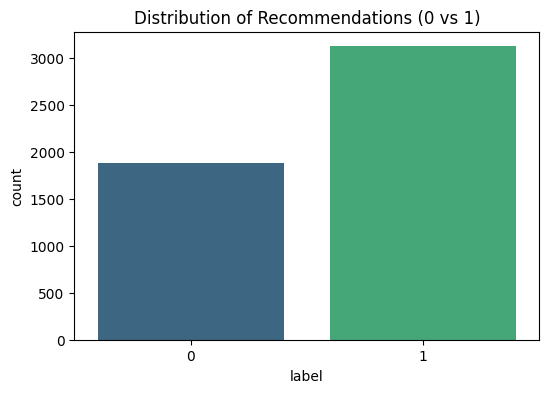

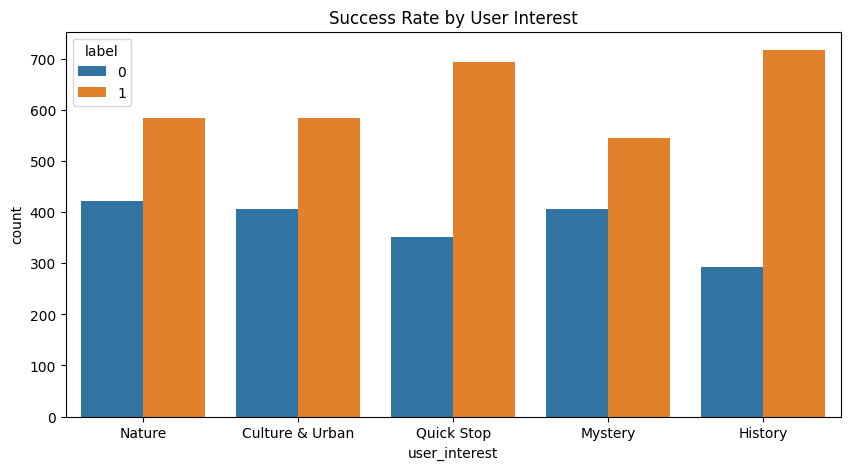

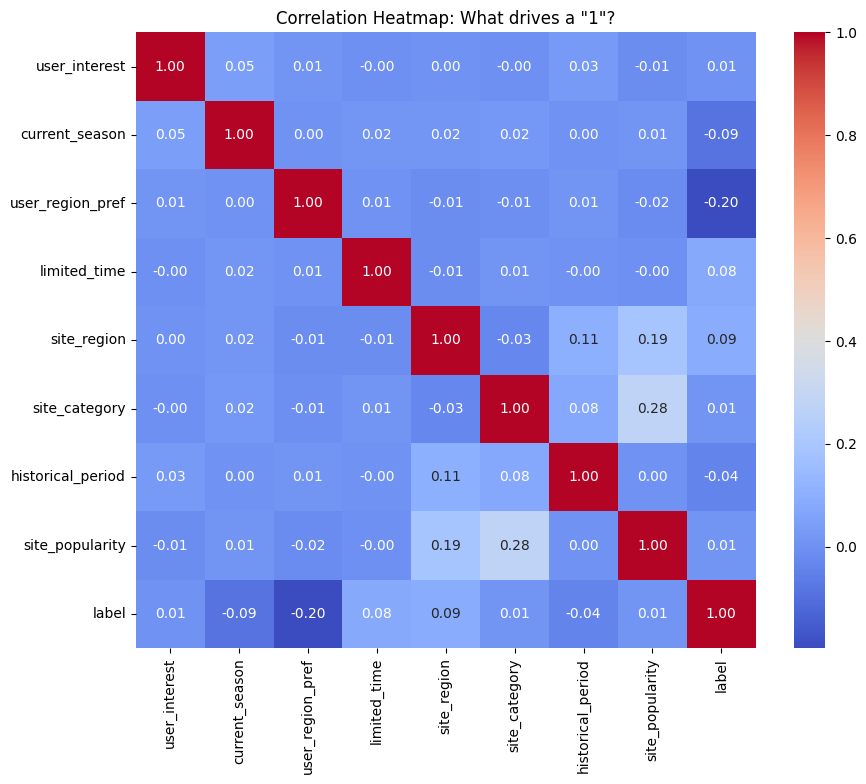

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=ultimate_train_df, palette='viridis')
plt.title('Distribution of Recommendations (0 vs 1)')
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(x='user_interest', hue='label', data=ultimate_train_df)
plt.title('Success Rate by User Interest')
plt.show()


# We encode just for the heatmap
eda_df = ultimate_train_df.copy()
for col in eda_df.select_dtypes(include=['object']).columns:
    eda_df[col] = LabelEncoder().fit_transform(eda_df[col])

plt.figure(figsize=(10, 8))
sns.heatmap(eda_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: What drives a "1"?')
plt.show()

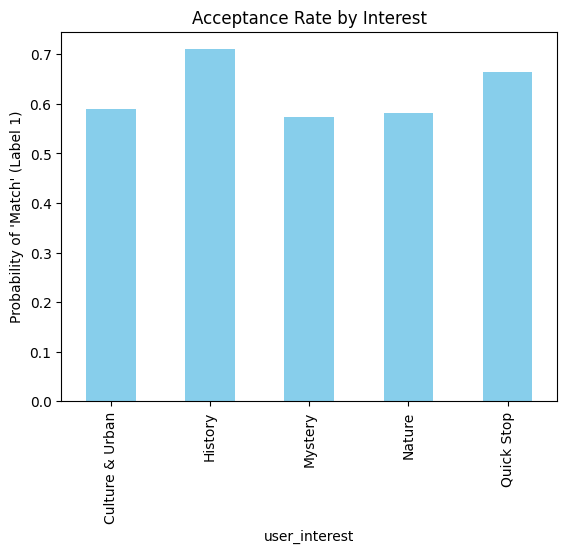

In [9]:
import matplotlib.pyplot as plt

ultimate_train_df.groupby('user_interest')['label'].mean().plot(kind='bar', color='skyblue')
plt.title("Acceptance Rate by Interest")
plt.ylabel("Probability of 'Match' (Label 1)")
plt.show()

#Phase 4 - Model Training (The Relevance Brain)

In [10]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# --- 0. CLEAN & RESET INDEXES ---
df = df.fillna({'region': 'Any', 'category': 'other', 'historical_period': 'Modern', 'popularity_level': 2})
ultimate_train_df = ultimate_train_df.dropna(subset=['label']).reset_index(drop=True)

# Clean nulls in training dataframe
ultimate_train_df['user_interest'] = ultimate_train_df['user_interest'].fillna('Nature')
ultimate_train_df['current_season'] = ultimate_train_df['current_season'].fillna('Summer')
ultimate_train_df['user_region_pref'] = ultimate_train_df['user_region_pref'].fillna('Any')
ultimate_train_df['limited_time'] = ultimate_train_df['limited_time'].fillna(0).astype(int)
ultimate_train_df['site_region'] = ultimate_train_df['site_region'].fillna('Any')
ultimate_train_df['site_category'] = ultimate_train_df['site_category'].fillna('other')
ultimate_train_df['site_popularity'] = ultimate_train_df['site_popularity'].fillna(2).astype(int)
ultimate_train_df['historical_period'] = ultimate_train_df['historical_period'].fillna('Modern')

# --- 1. DYNAMICALLY FIT ALL ENCODERS WITH UNKNOWN FALLBACK ('<UNKNOWN>') ---
def fit_safe_encoder(values_list):
    unique_vals = list(set([str(v).strip() for v in values_list if pd.notna(v)]))
    if '<UNKNOWN>' not in unique_vals:
        unique_vals.append('<UNKNOWN>')
    return LabelEncoder().fit(unique_vals)

le_interest = fit_safe_encoder(['History', 'Mystery', 'Nature', 'Quick Stop', 'Culture & Urban'] + list(ultimate_train_df['user_interest'].unique()))
le_season   = fit_safe_encoder(['Spring', 'Summer', 'Autumn', 'Winter'] + list(ultimate_train_df['current_season'].unique()))
le_region   = fit_safe_encoder(list(df['region'].unique()) + list(ultimate_train_df['user_region_pref'].unique()) + list(ultimate_train_df['site_region'].unique()) + ['Any'])

unique_cats = list(df['category'].unique()) + list(ultimate_train_df['site_category'].unique())
le_category = fit_safe_encoder(unique_cats)

unique_periods = list(df['historical_period'].unique()) + list(ultimate_train_df['historical_period'].unique())
le_period   = fit_safe_encoder(unique_periods)

le_pop      = fit_safe_encoder([1, 2, 3, '1', '2', '3'] + list(ultimate_train_df['site_popularity'].unique()))

# Safe Transform Function
def safe_transform(encoder, series):
    classes = set(encoder.classes_)
    cleaned = series.astype(str).str.strip().apply(lambda x: x if x in classes else '<UNKNOWN>')
    return encoder.transform(cleaned)

# --- 2. FEATURE PREPARATION ---
def prepare_final_features(df_input):
    df_clean = df_input.copy().reset_index(drop=True)
    X = pd.DataFrame()
    X['user_interest']  = safe_transform(le_interest, df_clean['user_interest'])
    X['current_season'] = safe_transform(le_season, df_clean['current_season'])
    X['user_region']    = safe_transform(le_region, df_clean['user_region_pref'])
    X['limited_time']   = df_clean['limited_time'].astype(int)
    X['site_region']    = safe_transform(le_region, df_clean['site_region'])
    X['site_category']  = safe_transform(le_category, df_clean['site_category'])
    X['site_pop']       = safe_transform(le_pop, df_clean['site_popularity'])
    X['period']         = safe_transform(le_period, df_clean['historical_period'])
    return X

# Prepare full dataset
X_full = prepare_final_features(ultimate_train_df)
y_full = ultimate_train_df['label'].reset_index(drop=True)

# Verify zero NaNs in X and y
assert X_full.isna().sum().sum() == 0, "X_full contains NaNs!"
assert y_full.isna().sum() == 0, "y_full contains NaNs!"

# --- 3. TRAIN / TEST SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

# --- 4. TRAIN CLASSIFIER ---
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',
    random_state=42
)
clf.fit(X_train, y_train)

# --- 5. EVALUATION ---
y_pred = clf.predict(X_test)
print("REALISTIC TEST EVALUATION (Unseen Test Set):")
print(classification_report(y_test, y_pred))

# --- 6. SAVE BRAIN PACKAGE ---
brain_package = {
    'model': clf,
    'le_interest': le_interest,
    'le_season': le_season,
    'le_region': le_region,
    'le_category': le_category,
    'le_period': le_period,
    'le_pop': le_pop
}

joblib.dump(brain_package, '/content/drive/MyDrive/Y2S1/MLSTProject/heritage_brain_v2.pkl')
print("✅ COMPLETE BRAIN PACKAGE SAVED TO DRIVE SUCCESSFULLY!")

REALISTIC TEST EVALUATION (Unseen Test Set):
              precision    recall  f1-score   support

           0       0.68      0.64      0.66       375
           1       0.79      0.82      0.80       625

    accuracy                           0.75      1000
   macro avg       0.73      0.73      0.73      1000
weighted avg       0.75      0.75      0.75      1000

✅ COMPLETE BRAIN PACKAGE SAVED TO DRIVE SUCCESSFULLY!


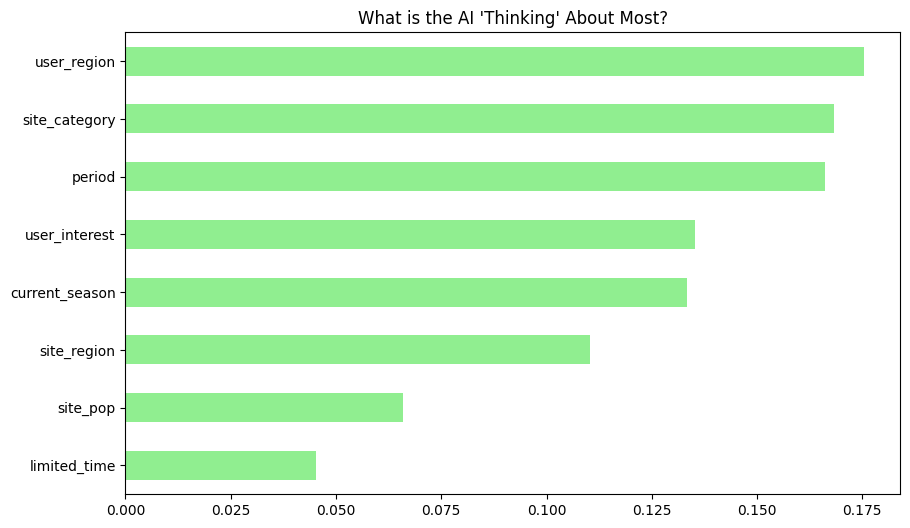

In [11]:
# Get importance
importances = clf.feature_importances_
feature_names = X_train.columns

# Plot
plt.figure(figsize=(10,6))
pd.Series(importances, index=feature_names).sort_values().plot(kind='barh', color='lightgreen')
plt.title("What is the AI 'Thinking' About Most?")
plt.show()

In [12]:
from sklearn.model_selection import cross_val_score

# Run 5-fold cross-validation on full feature dataset
scores = cross_val_score(clf, X_full, y_full, cv=5)

print(f"Cross-Validation Scores: {scores}")
print(f"Average Stability: {scores.mean():.2f} (+/- {scores.std() * 2:.2f})")

Cross-Validation Scores: [0.755 0.761 0.761 0.765 0.746]
Average Stability: 0.76 (+/- 0.01)


### 🏛️ Heritage Recommender: Hybrid Logic & Gastronomic Layer
This system combines three layers of intelligence:
1. **Semantic Search (ChromaDB):** Finds sites based on the user's natural language query.
2. **Supervised Learning (Random Forest):** Ranks those sites by predicting the probability of a "Match" based on user interest, region preference, and current season.
3. **Domain Heuristics (Gastronomic Heritage):** Automatically links the top recommendation to its regional culinary history to provide a complete cultural experience.

In [13]:
# --- 1. HERITAGE DICTIONARY ---
regional_food_heritage = {
    "sarajevo": "The heart of 'Sarajevski ćevapi' and traditional 'Aščinica' slow-cooked dishes like Begova čorba and Sogan dolma.",
    "banja luka": "Home of the unique four-tile 'Banjalučki ćevapi' served in a traditional lepinja.",
    "mostar": "Known for 'Jagnjetina' (lamb) and 'Mostarski šaran', reflecting the Mediterranean-Balkan mix.",
    "travnik": "Renowned for its specific Travnik-style ćevapi and the world-class Vlašić mountain sheep cheese.",
    "kiseljak": "Famous for 'Kiseljačke pogačice' made with local mineral water and heavy kajmak.",
    "tuzla": "Famous for 'Tuzlanski ćevapi' and historical influence of salt production on local food preservation.",
    "krajina": "Famous for 'Unska pastrmka' (Una river trout) and traditional 'Krajiška trahana'.",
    "herzegovina": "Look for 'Sir iz mijeha' (cheese in a sack), 'Pršut', and high-quality Žilavka and Blatina wines.",
    "hercegovina": "Look for 'Sir iz mijeha' (cheese in a sack), 'Pršut', and high-quality Žilavka and Blatina wines."
}

# --- 2. SAFE INFERENCE FEATURE PREPARATION ---
def prepare_inference_features(df_input):
    X = pd.DataFrame()

    # Robust encoder transformer using existing encoder classes dynamically
    def safe_transform(le, series):
        known = set(le.classes_)
        default_val = le.classes_[0]  # Uses the first fitted class directly
        cleaned = series.apply(lambda x: x if x in known else default_val)
        return le.transform(cleaned)

    X['user_interest']  = safe_transform(le_interest, df_input['user_interest'])
    X['current_season'] = safe_transform(le_season, df_input['current_season'])
    X['user_region']    = safe_transform(le_region, df_input['user_region_pref'])
    X['limited_time']   = df_input['limited_time']
    X['site_region']    = safe_transform(le_region, df_input['site_region'])
    X['site_category']  = safe_transform(le_category, df_input['site_category'])
    X['site_pop']       = safe_transform(le_pop, df_input['site_popularity'])
    X['period']         = safe_transform(le_period, df_input['historical_period'])
    return X

# --- 3. HYBRID RECOMMENDATION FUNCTION ---
def get_final_recommendation(query, reg_pref, interest, season, time_lim=0):
    reg_pref = reg_pref.replace("Hercegovina", "Herzegovina")

    hidden_keywords = ['hidden', 'quiet', 'secret', 'peaceful', 'away', 'mir', 'tišina', 'skriveno']
    prefers_hidden = any(word in query.lower() for word in hidden_keywords)

    results = collection.query(query_texts=[query], n_results=10)
    metadatas, ids = results['metadatas'][0], results['ids'][0]

    scored_candidates = []
    pop_to_num = {'A': 3, 'B': 2, 'C': 1}

    # Store exact case classes from fitted encoder
    known_categories = list(le_category.classes_)
    default_cat = known_categories[0]

    for i in range(len(metadatas)):
        site_meta = metadatas[i]

        raw_pop = str(site_meta.get('popularity_level', 'B')).strip().upper()
        clean_pop = pop_to_num.get(raw_pop, 2)

        # Match category using lower-case comparison but assign original fitted case
        raw_cat = str(site_meta.get('category', '')).lower().strip()
        clean_cat = default_cat
        for known in known_categories:
            if known.lower() in raw_cat:
                clean_cat = known
                break

        # Match period using original fitted case
        raw_period = str(site_meta.get('historical_period', '')).strip()
        clean_period = le_period.classes_[0]
        for known in le_period.classes_:
            if known.lower() == raw_period.lower():
                clean_period = known
                break

        candidate_df = pd.DataFrame([{
            'user_interest': interest.title(),
            'current_season': season.title(),
            'user_region_pref': reg_pref.title(),
            'limited_time': time_lim,
            'site_region': str(site_meta.get('region', le_region.classes_[0])).title(),
            'site_category': clean_cat,
            'historical_period': clean_period,
            'site_popularity': clean_pop
        }])

        X_feat = prepare_inference_features(candidate_df)
        ai_score = clf.predict_proba(X_feat)[0][1]

        pop_adjustment = (4 - clean_pop) * 0.1 if prefers_hidden else clean_pop * 0.05
        final_score = round((ai_score + pop_adjustment) * 100, 2)

        scored_candidates.append({
            'name': ids[i],
            'score': final_score,
            'region': site_meta.get('region', 'Sarajevo Region'),
            'pop_level': raw_pop
        })

    ranked = sorted(scored_candidates, key=lambda x: x['score'], reverse=True)

    if ranked:
        top = ranked[0]
        print(f"🥇 BEST MATCH: {top['name']} (Popularity: {top['pop_level']})")
        print(f"📈 Match Confidence: {top['score']}%")

        region_key = top['region'].lower()
        heritage_note = next((info for key, info in regional_food_heritage.items() if key in region_key), "Traditional local snacks!")
        print(f"✨ HERITAGE TIP: {heritage_note}")

        if len(ranked) > 1:
            second = ranked[1]
            if (top['score'] - second['score']) < 10:
                print(f"\n🥈 ALSO RECOMMENDED: {second['name']} ({second['score']}%)")
            else:
                print("\n📌 No other close matches found for this specific criteria.")

# --- LIVE TEST ---
get_final_recommendation("I want a quiet place for nature", "Hercegovina", "Nature", "Spring")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

🥇 BEST MATCH: Djevojacka Pecina (Maidens Cave) (Popularity: C)
📈 Match Confidence: 84.46%
✨ HERITAGE TIP: Traditional local snacks!

📌 No other close matches found for this specific criteria.


In [14]:
# Quick debug to see what is inside your metadata
debug_results = collection.query(query_texts=["Sarajevo"], n_results=1)
print("Your metadata keys are:", debug_results['metadatas'][0][0].keys())

Your metadata keys are: dict_keys(['popularity_level', 'location', 'tourism_season', 'name', 'historical_period', 'is_winter', 'is_autumn', 'latitude', 'is_summer', 'keywords', 'avg_visit_time', 'pop_num', 'region', 'era_group', 'description', 'category', 'source', 'longitude', 'is_spring', 'fun_fact', 'visit_time_num'])


In [15]:
# Test a single prediction with corrected case and types
sample_site = pd.DataFrame([{
    'user_interest': 'Nature',         # Interest might be Title Case
    'current_season': 'Summer',        # Season might be Title Case
    'user_region_pref': 'Sarajevo Region',
    'limited_time': 0,
    'site_region': 'Sarajevo Region',
    'site_category': 'nature',         # FIX: Lowercase to match training
    'site_popularity': 2,              # FIX: Numeric (2 for 'B') to match le_pop
    'historical_period': 'Natural'
}])

# Using your defined feature prep function
X_debug = prepare_final_features(sample_site)
raw_prob = clf.predict_proba(X_debug)
print(f"✅ AI Brain Debug Successful!")
print(f"Raw Probability of Match: {raw_prob[0][1]*100:.2f}%")

✅ AI Brain Debug Successful!
Raw Probability of Match: 66.00%


#Phase 4: Model Evaluation

We must prove the model works using a Classification Report.

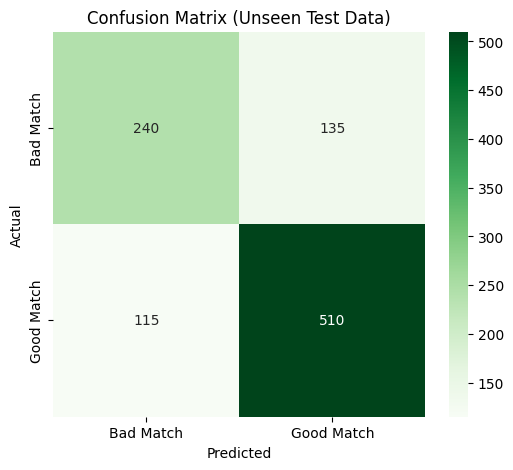

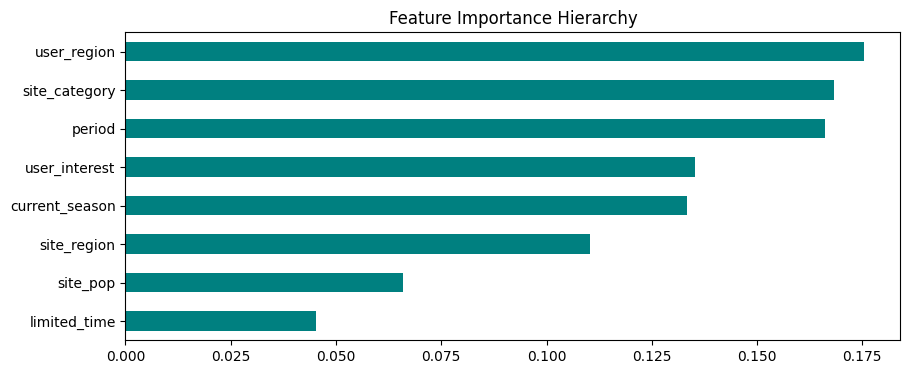


--- DETAILED TEST STATS ---
              precision    recall  f1-score   support

           0       0.68      0.64      0.66       375
           1       0.79      0.82      0.80       625

    accuracy                           0.75      1000
   macro avg       0.73      0.73      0.73      1000
weighted avg       0.75      0.75      0.75      1000



In [16]:
## PHASE 4: SCIENTIFIC EVALUATION
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on unseen test set
y_test_pred = clf.predict(X_test)

# 1. Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Bad Match', 'Good Match'], yticklabels=['Bad Match', 'Good Match'])
plt.title("Confusion Matrix (Unseen Test Data)")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 2. Feature Importance
plt.figure(figsize=(10, 4))
importances = pd.Series(clf.feature_importances_, index=X_train.columns)
importances.sort_values().plot(kind='barh', color='teal')
plt.title("Feature Importance Hierarchy")
plt.show()

print("\n--- DETAILED TEST STATS ---")
print(classification_report(y_test, y_test_pred))

In [17]:
importances = clf.feature_importances_
feature_names = X_train.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print("MODEL HIERARCHY:")
print(feat_imp)

MODEL HIERARCHY:
user_region       0.175284
site_category     0.168349
period            0.166081
user_interest     0.135324
current_season    0.133359
site_region       0.110243
site_pop          0.066002
limited_time      0.045357
dtype: float64


In [18]:
# Run this to see what your categories were
import  pandas as pd
df_check = pd.read_csv("/content/drive/MyDrive/Y2S1/MLSTProject/simulated_interaction_profiles.csv")

print("--- YOUR CATEGORIES ---")
print("Regions:", df_check['site_region'].unique())
print("Categories:", df_check['site_category'].unique())
print("Interests:", df_check['user_interest'].unique())
print("Seasons:", df_check['current_season'].unique())

--- YOUR CATEGORIES ---
Regions: ['Eastern Bosnia' 'Central Bosnia' 'Krajina' 'Northern Bosnia'
 'Herzegovina' 'Sarajevo Region']
Categories: ['monument' 'religious' 'fortress' 'nature' 'urban heritage' 'museum'
 'other heritage/leisure' 'archaeological' 'hidden gem'
 'traditional village']
Interests: ['Nature' 'Culture & Urban' 'Quick Stop' 'Mystery' 'History']
Seasons: ['Winter' 'Summer' 'Autumn' 'Spring']


In [19]:
# ==========================================
# SYSTEM CONFIGURATION & PATHS
# ==========================================

BASE_PROJECT_PATH = '/content/drive/My Drive/Y2S1/MLSTProject/'
PROFILES_FILENAME = 'simulated_interaction_profiles.csv'
MODEL_FILENAME    = 'heritage_rf_model.pkl'

# Combine them for the actual save
profiles_save_path = f"{BASE_PROJECT_PATH}{PROFILES_FILENAME}"

# --- SAVE DATA ---
ultimate_train_df.to_csv(profiles_save_path, index=False)

print(f"DATA PERSISTENCE: Profiles archived at {profiles_save_path}")

DATA PERSISTENCE: Profiles archived at /content/drive/My Drive/Y2S1/MLSTProject/simulated_interaction_profiles.csv


In [20]:
ultimate_train_df.head()

,user_interest,current_season,user_region_pref,limited_time,site_region,site_category,historical_period,site_popularity,label
0,Nature,Winter,Sarajevo Region,1,Eastern Bosnia,monument,Modern,3,0
1,Culture & Urban,Summer,Krajina,0,Central Bosnia,religious,Medieval,2,1
2,Quick Stop,Autumn,Sarajevo Region,1,Krajina,fortress,Medieval,1,0
3,Quick Stop,Summer,Northern Bosnia,1,Central Bosnia,nature,Modern,3,0
4,Quick Stop,Summer,Northern Bosnia,0,Northern Bosnia,fortress,Medieval/Ottoman,1,1


In [21]:
import os
import pandas as pd
import chromadb

csv_path = "/content/drive/MyDrive/Y2S1/MLSTProject/BiH_Heritage_Final_Clean.csv"

# 1. Inspect CSV File Directly
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f"Total Rows in DataFrame: {len(df)}")

    # Check Stari Most
    stari_mask = df.astype(str).apply(lambda row: row.str.contains('Stari Most', case=False)).any(axis=1)
    print(f"Matches for 'Stari Most': {stari_mask.sum()}")
    if stari_mask.sum() > 0:
        print(df[stari_mask][['name', 'location', 'category']].head(2))

    # Check Ponijeri again with stripped strings
    ponijeri_mask = df.astype(str).apply(lambda row: row.str.contains('Ponijeri', case=False)).any(axis=1)
    print(f"Matches for 'Ponijeri': {ponijeri_mask.sum()}")
else:
    print(f"File not found at {csv_path}")

print("\n" + "="*40 + "\n")

# 2. Inspect ChromaDB Collections across possible paths
possible_db_paths = ["heritage_db", "/content/heritage_db", "/content/drive/MyDrive/Y2S1/MLSTProject/heritage_db"]

for path in possible_db_paths:
    if os.path.exists(path):
        try:
            client = chromadb.PersistentClient(path=path)
            cols = client.list_collections()
            print(f"Path '{path}' exists. Collections found: {[c.name for c in cols]}")
            if "bih_heritage" in [c.name for c in cols]:
                col = client.get_collection("bih_heritage")
                print(f"  -> Total items in 'bih_heritage': {col.count()}")
        except Exception as e:
            print(f"Error accessing {path}: {e}")

Total Rows in DataFrame: 259
Matches for 'Stari Most': 3
                              name location  category
0                       Stari Most   mostar  monument
131  Old Bridge in Mostar (Museum)   mostar    museum
Matches for 'Ponijeri': 1


Path '/content/drive/MyDrive/Y2S1/MLSTProject/heritage_db' exists. Collections found: ['bih_heritage']
  -> Total items in 'bih_heritage': 294
